In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_csv("../data/raw/rom_rehabilitation_data.csv")

In [4]:
df.head(50)

,patient_id,session_number,date,age,gender,joint_type,treatment_type,rom_degrees,contact_force_n,pain_level,sessions_per_week,initial_rom,target_rom,rom_improvement,percent_improvement,weeks_in_treatment
0,P001,1,2023-03-16,63,F,ankle,Combined,26.0,2.86,8.3,2,26.0,41.6,0.0,0.0,1
1,P001,2,2023-03-23,63,F,ankle,Combined,26.0,6.33,8.3,2,26.0,41.6,0.0,0.0,2
2,P001,3,2023-03-30,63,F,ankle,Combined,28.0,4.40,5.9,4,26.0,41.6,2.0,12.8,3
3,P001,4,2023-04-06,63,F,ankle,Combined,28.1,3.40,5.4,3,26.0,41.6,2.1,13.5,4
4,P001,5,2023-04-13,63,F,ankle,Combined,30.2,4.80,6.3,3,26.0,41.6,4.2,26.9,5
5,P001,6,2023-04-20,63,F,ankle,Combined,30.8,4.70,4.0,4,26.0,41.6,4.8,30.8,6
6,P001,7,2023-04-27,63,F,ankle,Combined,27.8,2.10,3.9,2,26.0,41.6,1.8,11.5,7
7,P001,8,2023-05-04,63,F,ankle,Combined,35.1,6.10,4.0,4,26.0,41.6,9.1,58.3,8
8,P001,9,2023-05-11,63,F,ankle,Combined,33.1,3.09,3.7,3,26.0,41.6,7.1,45.5,9
9,P001,10,2023-05-18,63,F,ankle,Combined,32.5,3.25,2.7,2,26.0,41.6,6.5,41.7,10


In [5]:
#Categorical encoding for treatment_type
df = pd.get_dummies(df, columns=['treatment_type'], dtype=int)

In [6]:
df.head(50)

,patient_id,session_number,date,age,gender,joint_type,rom_degrees,contact_force_n,pain_level,sessions_per_week,initial_rom,target_rom,rom_improvement,percent_improvement,weeks_in_treatment,treatment_type_Combined,treatment_type_Exercise-Based,treatment_type_Home Program,treatment_type_Manual Therapy
0,P001,1,2023-03-16,63,F,ankle,26.0,2.86,8.3,2,26.0,41.6,0.0,0.0,1,1,0,0,0
1,P001,2,2023-03-23,63,F,ankle,26.0,6.33,8.3,2,26.0,41.6,0.0,0.0,2,1,0,0,0
2,P001,3,2023-03-30,63,F,ankle,28.0,4.40,5.9,4,26.0,41.6,2.0,12.8,3,1,0,0,0
3,P001,4,2023-04-06,63,F,ankle,28.1,3.40,5.4,3,26.0,41.6,2.1,13.5,4,1,0,0,0
4,P001,5,2023-04-13,63,F,ankle,30.2,4.80,6.3,3,26.0,41.6,4.2,26.9,5,1,0,0,0
5,P001,6,2023-04-20,63,F,ankle,30.8,4.70,4.0,4,26.0,41.6,4.8,30.8,6,1,0,0,0
6,P001,7,2023-04-27,63,F,ankle,27.8,2.10,3.9,2,26.0,41.6,1.8,11.5,7,1,0,0,0
7,P001,8,2023-05-04,63,F,ankle,35.1,6.10,4.0,4,26.0,41.6,9.1,58.3,8,1,0,0,0
8,P001,9,2023-05-11,63,F,ankle,33.1,3.09,3.7,3,26.0,41.6,7.1,45.5,9,1,0,0,0
9,P001,10,2023-05-18,63,F,ankle,32.5,3.25,2.7,2,26.0,41.6,6.5,41.7,10,1,0,0,0


In [7]:
#Age grouping
df["age_group"] = pd.cut(df["age"], bins=[20, 40, 60, float("inf")], labels=["20-40", "40-60", "60+"], right=False)

In [8]:
#Encode age_group to numeric columns
df = pd.get_dummies(df, columns=['age_group'], dtype=int)

In [9]:
df.head()

,patient_id,session_number,date,age,gender,joint_type,rom_degrees,contact_force_n,pain_level,sessions_per_week,...,rom_improvement,percent_improvement,weeks_in_treatment,treatment_type_Combined,treatment_type_Exercise-Based,treatment_type_Home Program,treatment_type_Manual Therapy,age_group_20-40,age_group_40-60,age_group_60+
0,P001,1,2023-03-16,63,F,ankle,26.0,2.86,8.3,2,...,0.0,0.0,1,1,0,0,0,0,0,1
1,P001,2,2023-03-23,63,F,ankle,26.0,6.33,8.3,2,...,0.0,0.0,2,1,0,0,0,0,0,1
2,P001,3,2023-03-30,63,F,ankle,28.0,4.40,5.9,4,...,2.0,12.8,3,1,0,0,0,0,0,1
3,P001,4,2023-04-06,63,F,ankle,28.1,3.40,5.4,3,...,2.1,13.5,4,1,0,0,0,0,0,1
4,P001,5,2023-04-13,63,F,ankle,30.2,4.80,6.3,3,...,4.2,26.9,5,1,0,0,0,0,0,1


In [10]:
#Categorical encoding for joint_type
df = pd.get_dummies(df, columns=['joint_type'], dtype=int)

In [11]:
df.head()

,patient_id,session_number,date,age,gender,rom_degrees,contact_force_n,pain_level,sessions_per_week,initial_rom,...,treatment_type_Home Program,treatment_type_Manual Therapy,age_group_20-40,age_group_40-60,age_group_60+,joint_type_ankle,joint_type_elbow,joint_type_knee,joint_type_shoulder,joint_type_wrist
0,P001,1,2023-03-16,63,F,26.0,2.86,8.3,2,26.0,...,0,0,0,0,1,1,0,0,0,0
1,P001,2,2023-03-23,63,F,26.0,6.33,8.3,2,26.0,...,0,0,0,0,1,1,0,0,0,0
2,P001,3,2023-03-30,63,F,28.0,4.40,5.9,4,26.0,...,0,0,0,0,1,1,0,0,0,0
3,P001,4,2023-04-06,63,F,28.1,3.40,5.4,3,26.0,...,0,0,0,0,1,1,0,0,0,0
4,P001,5,2023-04-13,63,F,30.2,4.80,6.3,3,26.0,...,0,0,0,0,1,1,0,0,0,0


In [12]:
df.to_csv("../data/processed/rom_rehabilitation_data_prepared.csv", index=False)



In [13]:
#Convert `date` to datetime and numeric days since earliest session
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days
df = df.drop(columns=['date'])

In [14]:
df.head()

,patient_id,session_number,age,gender,rom_degrees,contact_force_n,pain_level,sessions_per_week,initial_rom,target_rom,...,treatment_type_Manual Therapy,age_group_20-40,age_group_40-60,age_group_60+,joint_type_ankle,joint_type_elbow,joint_type_knee,joint_type_shoulder,joint_type_wrist,days_since_start
0,P001,1,63,F,26.0,2.86,8.3,2,26.0,41.6,...,0,0,0,1,1,0,0,0,0,72
1,P001,2,63,F,26.0,6.33,8.3,2,26.0,41.6,...,0,0,0,1,1,0,0,0,0,79
2,P001,3,63,F,28.0,4.40,5.9,4,26.0,41.6,...,0,0,0,1,1,0,0,0,0,86
3,P001,4,63,F,28.1,3.40,5.4,3,26.0,41.6,...,0,0,0,1,1,0,0,0,0,93
4,P001,5,63,F,30.2,4.80,6.3,3,26.0,41.6,...,0,0,0,1,1,0,0,0,0,100


In [15]:
#Ensure all features are numeric (encode any remaining object/category columns)
df = pd.get_dummies(df, dtype=int)

In [16]:
X = df.drop(columns=["rom_improvement"])
y = df["rom_improvement"]


In [17]:
X.shape, y.shape

((600, 75), (600,))

In [18]:
X.to_csv("../data/processed/X.csv", index=False)
y.to_csv("../data/processed/y.csv", index=False)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print(X_train.size)
print(X_test.size)
print(y_train.size)
print(y_test.size)

36000
9000
480
120


In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(480, 75)
(120, 75)
(480,)
(120,)


Text(0.5, 0, 'ROM Improvement')

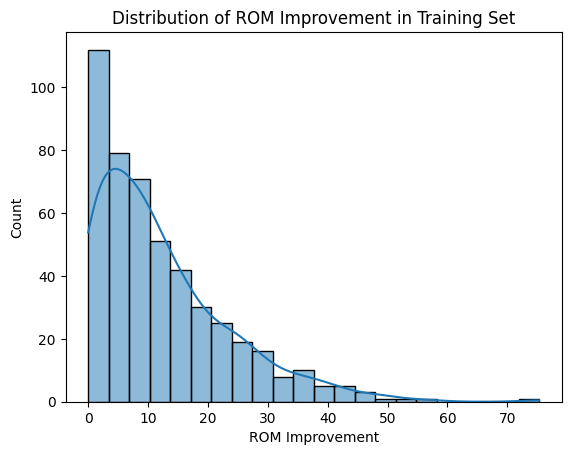

In [22]:
sns.histplot(y_train, kde=True)
plt.title("Distribution of ROM Improvement in Training Set")
plt.xlabel("ROM Improvement")

Text(0.5, 0, 'ROM Improvement')

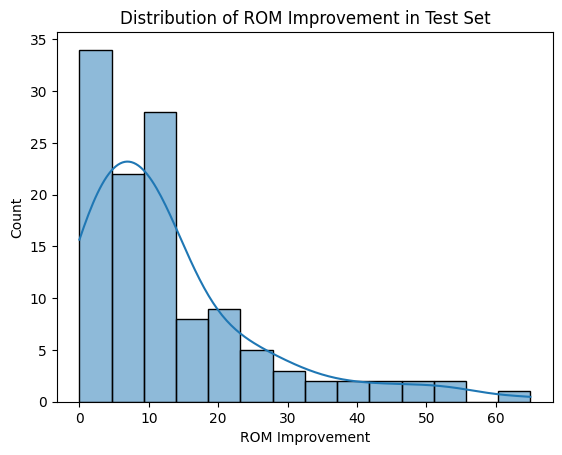

In [23]:
sns.histplot(y_test, kde=True)
plt.title("Distribution of ROM Improvement in Test Set")
plt.xlabel("ROM Improvement")

In [24]:
model = LinearRegression()

In [25]:
print(X_train.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


In [26]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
print(model.coef_)
print(model.intercept_)

[ 1.38655315e-06  7.40639895e-07  1.00000000e+00  9.36750677e-16
  1.66533454e-16 -2.66453526e-15 -9.99842137e-01 -1.01929150e-04
 -1.99840144e-15  1.38655315e-06 -2.02312639e-04 -2.12547928e-06
  1.37326286e-04  6.71118324e-05 -2.99912589e-04 -2.95229440e-04
  5.95142030e-04  8.63155657e-04 -1.21875134e-03 -2.15680238e-03
  1.84702418e-03  6.65373885e-04 -3.96158042e-07 -1.05083927e-03
  1.17034127e-04  1.40462658e-03 -4.97395538e-04  5.24146809e-04
 -1.43070016e-04 -2.78682860e-03 -1.78364579e-03  3.21785701e-04
 -2.71503401e-03  8.90101666e-05  2.96348303e-03 -1.64898762e-03
 -2.96408247e-03 -3.52831352e-03  1.62761489e-03  3.47672789e-04
  1.25321420e-03  6.71538967e-04  1.15827136e-03 -1.69580377e-03
  2.08577388e-03  3.35760907e-04  4.24249523e-04 -1.54056902e-03
 -2.57112590e-03 -3.42255599e-04  1.14220443e-04 -9.48982741e-04
  1.18771100e-03 -8.20092584e-04  4.22035256e-04  5.14505707e-04
  2.23537394e-03  8.46175138e-04  6.79687857e-05  1.31180168e-03
 -2.32873911e-03 -8.90861

In [28]:
y_pred = model.predict(X_test)

In [29]:
for value in range(10):
    print(f"Predicted: {y_pred[value]:.2f}, Actual: {y_test.iloc[value]:.2f}")

Predicted: 2.40, Actual: 2.40
Predicted: 55.10, Actual: 55.10
Predicted: 2.80, Actual: 2.80
Predicted: 5.60, Actual: 5.60
Predicted: -0.00, Actual: 0.00
Predicted: 4.50, Actual: 4.50
Predicted: 9.50, Actual: 9.50
Predicted: 4.00, Actual: 4.00
Predicted: 6.00, Actual: 6.00
Predicted: 2.70, Actual: 2.70


In [30]:
mse_value = mean_squared_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)
rmse_value = root_mean_squared_error(y_test, y_pred)
mae_value = mean_absolute_error(y_test, y_pred)

In [31]:
print(mse_value)
print(r2_value)
print(rmse_value)
print(mae_value)

1.4461937430132227e-26
1.0
1.2025779571459068e-13
9.773645470780949e-14


Text(0.5, 1.0, 'Actual vs Predicted ROM Improvement')

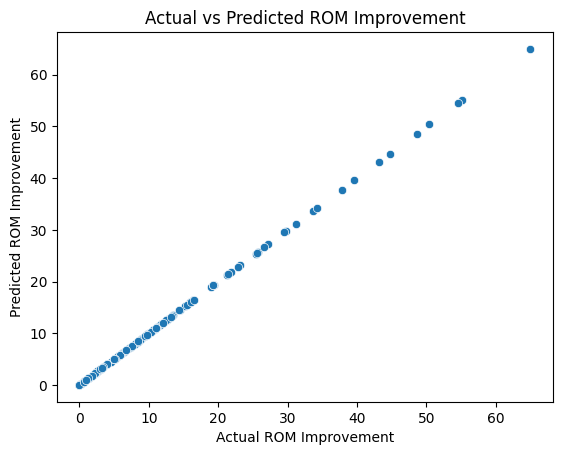

In [32]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual ROM Improvement")
plt.ylabel("Predicted ROM Improvement")
plt.title("Actual vs Predicted ROM Improvement")

0    0.0
1    0.0
2    2.0
3    2.1
4    4.2
Name: rom_improvement, dtype: float64
